# Artificial Neural Networks and Deep Learning

## Homework 2 - FORmidable
---

## ⚙️ Import Libraries

In [1]:
# All the comments in this notebook only corresponds to new parts, please refer to our baseline notebook for more details.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras as tfk
from keras import layers as tfkl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")

on_kaggle = True

GPU devices: 2
TensorFlow version: 2.16.1
Keras version: 3.3.3


## ⏳ Load and Visualize the Data

In [2]:
if (on_kaggle):
    %cd "/kaggle/input"
    data = np.load("mars-dataset/mars_for_students.npz")
else: 
    data = np.load("mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]
X_test_original = data["test_set"]

print(f"Training X shape: {X_train_original.shape}")
print(f"Training y shape: {y_train_original.shape}")
print(f"Test X shape: {X_test_original.shape}")

/kaggle/input
Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


In [3]:
colors = ['black', 'saddlebrown', 'gray', 'khaki', 'blue']
label_names = ['background', 'soil', 'bedrock', 'sand', 'big rock']

cmap = plt.cm.colors.ListedColormap(colors)

def plot_image_label(images, labels, num_rows, num_cols, range_max):
    _, axes = plt.subplots(num_rows, 2 * num_cols, figsize=(4*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j * 2].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j * 2].axis('off')
            axes[i, j * 2 + 1].imshow(labels[idx], cmap=cmap, vmin=0, vmax=4)
            axes[i, j * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
#plot_image_label(X_train_original, y_train_original, 6, 3, 255)

In [4]:
def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)
    mask[indices_to_remove] = False
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

label_to_remove = y_train_original[2561]

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

X_train_original = X_train_cleaned
y_train_original = y_train_cleaned

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


In [5]:
def plot_distribution(lbl):
    if isinstance(lbl, tf.Tensor):
        lbl = lbl.numpy()

    label_counts = np.bincount(lbl.flatten().astype(int))
    total_count = np.sum(label_counts)
    label_4_percentage = (label_counts[4] / total_count) * 100 if 4 < len(label_counts) else 0
    
    label_counts = np.bincount(lbl.flatten().astype(int))
    plt.figure(figsize=(7, 4))
    plt.bar(label_names, label_counts, color=colors)
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.title("Label Distribution")

    if 4 < len(label_counts):
        plt.text(4, label_counts[4] + total_count * 0.02,
                 f"{label_4_percentage:.2f}%", 
                 ha='center', fontsize=10)
        
    plt.show()

## Prepare the dataset

In [6]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 30
EPOCHS = 1000
SPLITS_SIZE = 300
SEED = 42

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Flatten the label array to get pixel-wise counts
flat_labels = y_train_original.flatten().astype(int)

# Compute the class weights using sklearn
class_labels = [0, 1, 2, 3, 4]  # Classes: Background, Soil, Bedrock, Sand, Big Rock
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=flat_labels
)

# Convert the result into a dictionary
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
class_weights_dict[4] /= 20

print("Computed class weights:", class_weights_dict)

Computed class weights: {0: 0.8226769183771894, 1: 0.5898914242365618, 2: 0.8591909663562084, 3: 1.088407490884616, 4: 7.610785150020398}


In [8]:
def apply_preprocessing(images):
    images = images[..., tf.newaxis] / 255.0
    ret = []
    for image in images:
        mean_brightness = tf.reduce_mean(image)
        delta = 1.0 * (0.5 - mean_brightness)
        image = tf.image.adjust_brightness(image, delta=delta)
        image = tf.image.adjust_contrast(image, contrast_factor=3.0)
        image = tf.clip_by_value(image, 0.0, 1.0) 
        ret.append(image)
    return np.array(ret)

X_train = apply_preprocessing(X_train_original)
y_train = y_train_original[..., tf.newaxis]

X_train = tf.cast(X_train, tf.float32)
y_train = tf.cast(y_train, tf.int32)

In [9]:
train_img, val_img, train_lbl, val_lbl = train_test_split(X_train.numpy().squeeze(), y_train.numpy().squeeze(), test_size=SPLITS_SIZE)
print("Data splitted!")
print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

train_img = train_img[..., tf.newaxis]
val_img = val_img[..., tf.newaxis]
train_lbl = train_lbl[..., tf.newaxis]
val_lbl = val_lbl[..., tf.newaxis]

Data splitted!

Number of images:
Train: 2205
Validation: 300


In [10]:
def augment_images(image, label, n_aug_0123, n_aug_4, seed=SEED):
    n_augmentations = tf.cond(
        tf.reduce_any(tf.equal(label, 4)),
        lambda: tf.constant(n_aug_4), 
        lambda: tf.constant(n_aug_0123)      
    )

    augmented_images = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_labels = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_images = augmented_images.write(0, image)
    augmented_labels = augmented_labels.write(0, label)

    for i in tf.range(1, n_augmentations+1):
        augmented_image, augmented_label = image, label

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_left_right(augmented_image)
            augmented_label = tf.image.flip_left_right(augmented_label)

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_up_down(augmented_image)
            augmented_label = tf.image.flip_up_down(augmented_label)

        if tf.random.uniform(()) > 0.2:
            noise = tf.random.normal(shape=tf.shape(augmented_image), mean=0.0, stddev=0.008)
            augmented_image = tf.clip_by_value(augmented_image + noise, 0.0, 1.0)

        if tf.random.uniform(()) > 0.2:
            zoom_factor = tf.random.uniform([], minval=1, maxval=1.2, dtype=tf.float32, seed=seed)
            central_fraction = 1.0 / zoom_factor
            zoom_image = tf.image.central_crop(augmented_image, central_fraction)
            zoom_label = tf.image.central_crop(augmented_label, central_fraction)
            augmented_image = tf.image.resize(zoom_image, tf.shape(image)[0:2])
            augmented_label = tf.image.resize(zoom_label, tf.shape(label)[0:2])

        augmented_images = augmented_images.write(i, augmented_image)
        augmented_labels = augmented_labels.write(i, augmented_label)

    return augmented_images.stack(), augmented_labels.stack()

In [11]:
def make_dataset(images, labels, batch_size, shuffle, augment=False, n_aug0123=1, n_aug_4=2, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augmentation_map(image, label):
            augmented_images, augmented_labels = augment_images(image, label, n_aug0123, n_aug_4, seed=seed)
            return tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
        dataset = dataset.flat_map(augmentation_map)
    
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_lbl, batch_size=BATCH_SIZE, shuffle=True, augment=True, n_aug0123=1, n_aug_4=2)
val_dataset = make_dataset(val_img, val_lbl, batch_size=BATCH_SIZE, shuffle=False)
print("Datasets created!")

for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"Input shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    break

total_images = 0
for images, labels in train_dataset:
    total_images += images.shape[0]

print(f"Total number of images in train_dataset: {total_images}")

Datasets created!
Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Total number of images in train_dataset: 4470


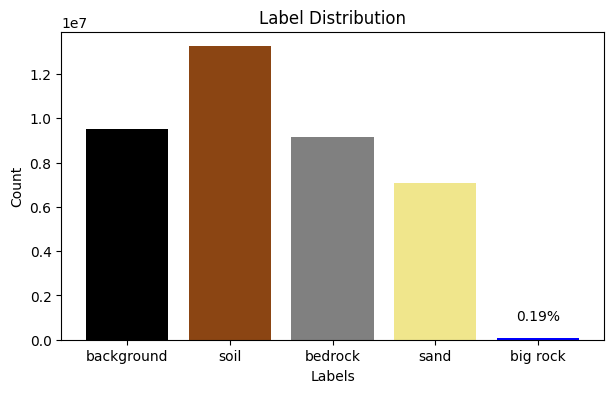

In [12]:
aug_labels = tf.concat(
    [
        tf.concat([labels for _, labels in train_dataset], axis=0),
        tf.concat([labels for _, labels in val_dataset], axis=0)
    ],
    axis=0
)

plot_distribution(aug_labels)

## 🛠️ Train and Save the Model

In [13]:
def unet_block(input_tensor, filters, kernel_size=3, activation='relu', stack=2, name=''):
    """UNet block with Conv2D, BatchNormalization, Activation, and Dropout."""
    x = input_tensor
    for i in range(stack):
        x = tfkl.Conv2D(filters, kernel_size=kernel_size, padding='same', name=name + 'conv' + str(i + 1))(x)
        x = tfkl.BatchNormalization(name=name + 'bn' + str(i + 1))(x)
        x = tfkl.Activation(activation, name=name + 'activation' + str(i + 1))(x)
    x = tfkl.Dropout(0.3)(x)  # Add dropout
    return x

def build_unet(input_tensor, num_classes, filters_base=64, name_prefix=''):
    """Single UNet."""
    # Downsampling
    down_block_1 = unet_block(input_tensor, filters_base, name=name_prefix + 'down_block1_')
    d1 = tfkl.MaxPooling2D()(down_block_1)
    
    down_block_2 = unet_block(d1, filters_base * 2, name=name_prefix + 'down_block2_')
    d2 = tfkl.MaxPooling2D()(down_block_2)

    # Bottleneck
    bottleneck = unet_block(d2, filters_base * 4, name=name_prefix + 'bottleneck')
    
    # Upsampling
    u1 = tfkl.UpSampling2D()(bottleneck)
    u1 = tfkl.Concatenate()([u1, down_block_2])
    up_block_1 = unet_block(u1, filters_base * 2, name=name_prefix + 'up_block1_')

    u2 = tfkl.UpSampling2D()(up_block_1)
    u2 = tfkl.Concatenate()([u2, down_block_1])
    up_block_2 = unet_block(u2, filters_base, name=name_prefix + 'up_block2_')

    # Output layer
    output = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation='softmax', name=name_prefix + 'output_layer')(up_block_2)
    return output

def get_double_unet(input_shape, num_classes=5, seed=42):
    """Double UNet model."""
    tf.random.set_seed(seed)
    
    # Input layer
    input_layer = tfkl.Input(shape=input_shape, name='input_layer')
    
    # First UNet (Global Segmentation)
    global_output = build_unet(input_layer, num_classes, filters_base=64, name_prefix='global_')
    
    # Concatenate global segmentation output back to the input for refinement
    global_output_conv = tfkl.Conv2D(input_shape[-1], kernel_size=1, padding='same', name='global_output_conv')(global_output)
    combined_input = tfkl.Concatenate(name='refinement_input')([input_layer, global_output_conv])
    
    # Second UNet (Local Segmentation)
    refined_output = build_unet(combined_input, num_classes, filters_base=64, name_prefix='local_')
    
    # Final model
    model = tf.keras.Model(inputs=input_layer, outputs=refined_output, name='Double_UNet')
    return model

Model: "Double_UNet"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 64, 128, │         0 │ -              │   -   │
│ (InputLayer)      │ 1)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       640 │ input_layer[0… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       256 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │    36,928 │ global_down_b… │   Y   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │       256 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 64, 128, │         0 │ global_down_b… │   -   │
│                   │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d     │ (None, 32, 64,  │         0 │ dropout[0][0]  │   -   │
│ (MaxPooling2D)    │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │    73,856 │ max_pooling2d… │   Y   │
│ (Conv2D)          │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │       512 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │         0 │ global_down_b… │   -   │
│ (Activation)      │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │   147,584 │ global_down_b… │   Y   │
│ (Conv2D)          │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │       512 │ global_down_b… │   Y   │
│ (BatchNormalizat… │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_down_bloc… │ (None, 32, 64,  │         0 │ global_down_b… │   -   │
│ (Activation)      │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 32, 64,  │         0 │ global_down_b… │   -   │
│ (Dropout)         │ 128)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ max_pooling2d_1   │ (None, 16, 32,  │         0 │ dropout_1[0][… │   - 

 Total params: 3,775,312 (14.40 MB)

 Trainable params: 3,770,192 (14.38 MB)

 Non-trainable params: 5,120 (20.00 KB)

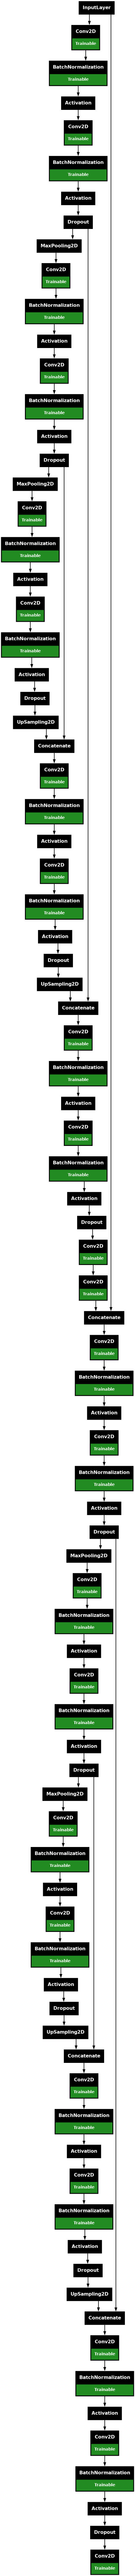

In [14]:
model = get_double_unet(input_shape=input_shape)
model.summary(expand_nested=True, show_trainable=True)
tf.keras.utils.plot_model(model, to_file='/kaggle/working/model.png', show_trainable=True, expand_nested=True, dpi=70)

In [15]:
class VizCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, frequency, n):
        super().__init__()
        self.val_dataset = val_dataset  # Take the validation dataset
        self.frequency = frequency
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            # Extract a batch from the validation dataset
            val_batch = next(iter(self.val_dataset))  # Take one batch
            images, labels = val_batch  # Unbatch the data
            n = min(self.n, len(images))  # Ensure we don't exceed available images
            
            preds = self.model.predict(images, verbose=0)
            #print("\n 1 pixel prediction:", preds[0][0][0])
            y_preds = tf.math.argmax(preds, axis=-1).numpy()  # Convert predictions to numpy
            #print("1 pixel prediction argmax:", y_preds[0][0][0])

            # Determine rows and columns for plotting
            rows = (n + 1) // 2  # Calculate rows needed for 2 images per row
            plt.figure(figsize=(12, rows))  # Adjust figure size for rows

            for i in range(n):
                col = (i % 2) * 3  # Columns in each row (3 subplots per image)
                row = i // 2       # Current row

                # Input image
                plt.subplot(rows, 6, row * 6 + col + 1)
                plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
                plt.title(f"Input {i + 1}")
                plt.axis('off')

                # Ground truth
                plt.subplot(rows, 6, row * 6 + col + 2)
                plt.imshow(labels[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Ground Truth {i + 1}")
                plt.axis('off')

                # Prediction
                plt.subplot(rows, 6, row * 6 + col + 3)
                plt.imshow(y_preds[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Prediction {i + 1}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

Model compiled!
Epoch 1/1000


I0000 00:00:1734190180.959125      67 service.cc:145] XLA service 0x7f2b14002e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734190180.959201      67 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1734190180.959206      67 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1734190181.670468      67 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1734190263.248660      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     69/Unknown 115s 264ms/step - accuracy: 0.3778 - loss: 1.2390 - mean_iou: 0.1838

W0000 00:00:1734190281.979075      66 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


     70/Unknown 236s 2s/step - accuracy: 0.3792 - loss: 1.2363 - mean_iou: 0.1848   

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
W0000 00:00:1734190404.370258      66 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1734190405.845160      69 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


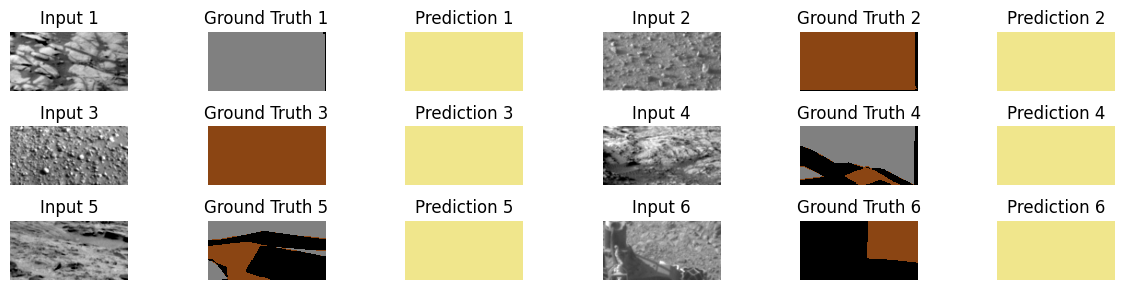

70/70 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.3806 - loss: 1.2338 - mean_iou: 0.1858 - val_accuracy: 0.2171 - val_loss: 4.1101 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 2/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 270ms/step - accuracy: 0.5999 - loss: 0.8953 - mean_iou: 0.3490 - val_accuracy: 0.2263 - val_loss: 5.3706 - val_mean_iou: 0.0217 - learning_rate: 0.0010
Epoch 3/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.6235 - loss: 0.8404 - mean_iou: 0.3613 - val_accuracy: 0.2172 - val_loss: 3.9048 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 4/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 251ms/step - accuracy: 0.6397 - loss: 0.8009 - mean_iou: 0.3763 - val_accuracy: 0.2171 - val_loss: 4.5958 - val_mean_iou: 0.0715 - learning_rate: 0.0010
Epoch 5/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 254ms/step - accuracy: 0.6469 - loss: 0.7777 - mean_iou: 0.3809 - val_accuracy: 0.2171 - val_loss: 3.5473 - val_mean_iou: 0.0572 - learning_rate: 0.0010
Epoch 6/1000
70/70 ━━━━━━━━━━━

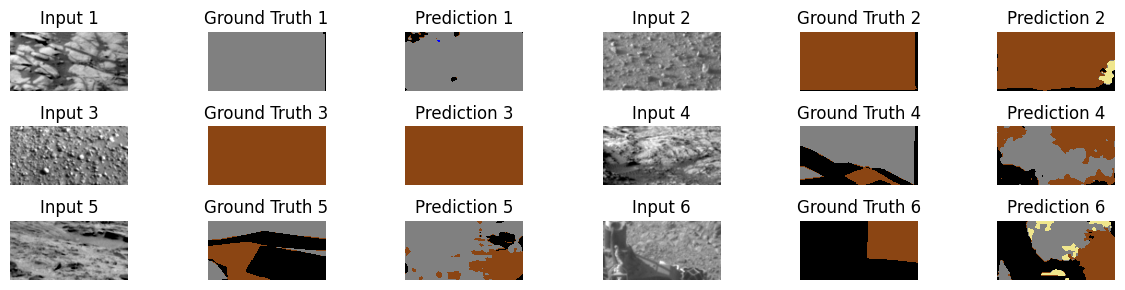

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.6945 - loss: 0.6887 - mean_iou: 0.4236 - val_accuracy: 0.6229 - val_loss: 1.0530 - val_mean_iou: 0.3349 - learning_rate: 0.0010
Epoch 12/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.6978 - loss: 0.6859 - mean_iou: 0.4262 - val_accuracy: 0.5933 - val_loss: 1.2547 - val_mean_iou: 0.3148 - learning_rate: 0.0010
Epoch 13/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.6940 - loss: 0.6943 - mean_iou: 0.4192 - val_accuracy: 0.6368 - val_loss: 1.0666 - val_mean_iou: 0.3631 - learning_rate: 0.0010
Epoch 14/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.7075 - loss: 0.6654 - mean_iou: 0.4368 - val_accuracy: 0.6519 - val_loss: 0.9156 - val_mean_iou: 0.3742 - learning_rate: 0.0010
Epoch 15/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7084 - loss: 0.6602 - mean_iou: 0.4375 - val_accuracy: 0.6387 - val_loss: 0.9808 - val_mean_iou: 0.3753 - learning_rate: 0.0010
Epoch 16/1000
70/70 ━━━━

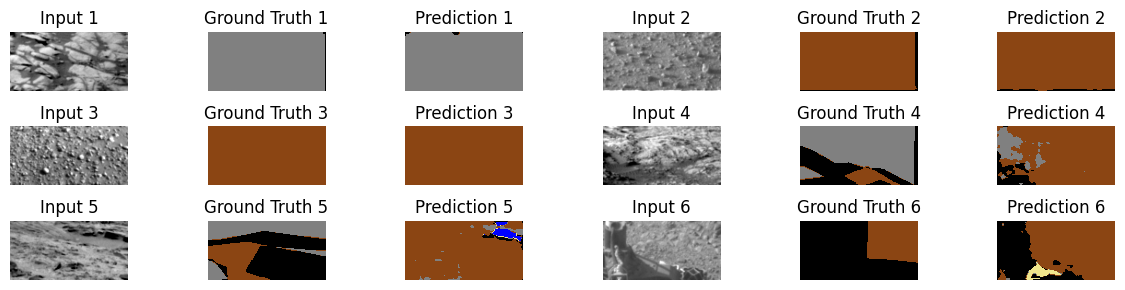

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.7196 - loss: 0.6322 - mean_iou: 0.4608 - val_accuracy: 0.6042 - val_loss: 1.0647 - val_mean_iou: 0.3102 - learning_rate: 0.0010
Epoch 22/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7230 - loss: 0.6231 - mean_iou: 0.4621 - val_accuracy: 0.6650 - val_loss: 0.8805 - val_mean_iou: 0.4081 - learning_rate: 0.0010
Epoch 23/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.7254 - loss: 0.6171 - mean_iou: 0.4628 - val_accuracy: 0.6309 - val_loss: 1.0718 - val_mean_iou: 0.3378 - learning_rate: 0.0010
Epoch 24/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.7255 - loss: 0.6107 - mean_iou: 0.4608 - val_accuracy: 0.6691 - val_loss: 0.9324 - val_mean_iou: 0.4000 - learning_rate: 0.0010
Epoch 25/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7304 - loss: 0.5990 - mean_iou: 0.4797 - val_accuracy: 0.6019 - val_loss: 1.1801 - val_mean_iou: 0.3394 - learning_rate: 0.0010
Epoch 26/1000
70/70 ━━━━

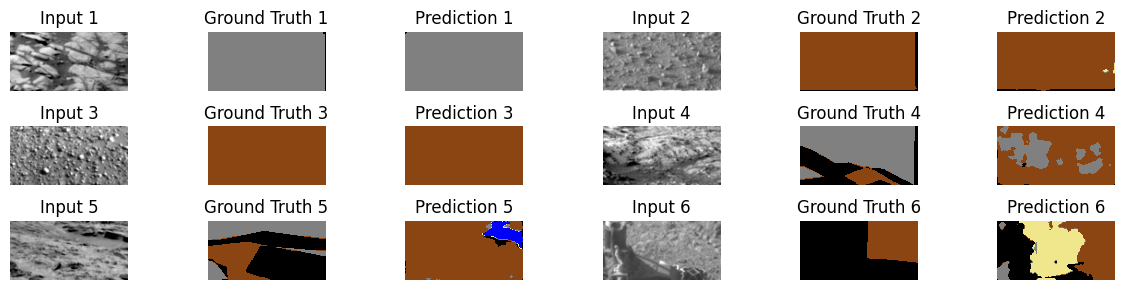

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 272ms/step - accuracy: 0.7400 - loss: 0.5685 - mean_iou: 0.4973 - val_accuracy: 0.5988 - val_loss: 1.1562 - val_mean_iou: 0.3185 - learning_rate: 0.0010
Epoch 32/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7424 - loss: 0.5668 - mean_iou: 0.4980
Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.7424 - loss: 0.5668 - mean_iou: 0.4979 - val_accuracy: 0.6056 - val_loss: 1.1059 - val_mean_iou: 0.3015 - learning_rate: 0.0010
Epoch 33/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7547 - loss: 0.5409 - mean_iou: 0.5226 - val_accuracy: 0.6382 - val_loss: 0.9865 - val_mean_iou: 0.3635 - learning_rate: 5.0000e-04
Epoch 34/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7598 - loss: 0.5215 - mean_iou: 0.5369 - val_accuracy: 0.6206 - val_loss: 1.0982 - val_mean_iou: 0.3539 - learning_rate: 5.0000e-04
Epoch 35/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18

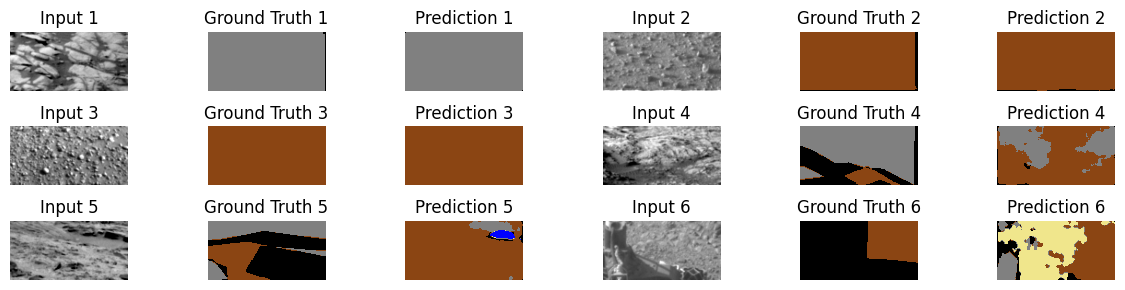

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 272ms/step - accuracy: 0.7731 - loss: 0.4868 - mean_iou: 0.5678 - val_accuracy: 0.5487 - val_loss: 1.3882 - val_mean_iou: 0.3086 - learning_rate: 5.0000e-04
Epoch 42/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7737 - loss: 0.4874 - mean_iou: 0.5675
Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7738 - loss: 0.4872 - mean_iou: 0.5674 - val_accuracy: 0.5851 - val_loss: 1.2108 - val_mean_iou: 0.3341 - learning_rate: 5.0000e-04
Epoch 43/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.7806 - loss: 0.4686 - mean_iou: 0.5875 - val_accuracy: 0.5453 - val_loss: 1.4430 - val_mean_iou: 0.3062 - learning_rate: 2.5000e-04
Epoch 44/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.7826 - loss: 0.4619 - mean_iou: 0.6014 - val_accuracy: 0.5638 - val_loss: 1.2738 - val_mean_iou: 0.3136 - learning_rate: 2.5000e-04
Epoch 45/1000
70/70 ━━━━━━━━━━━━━━━

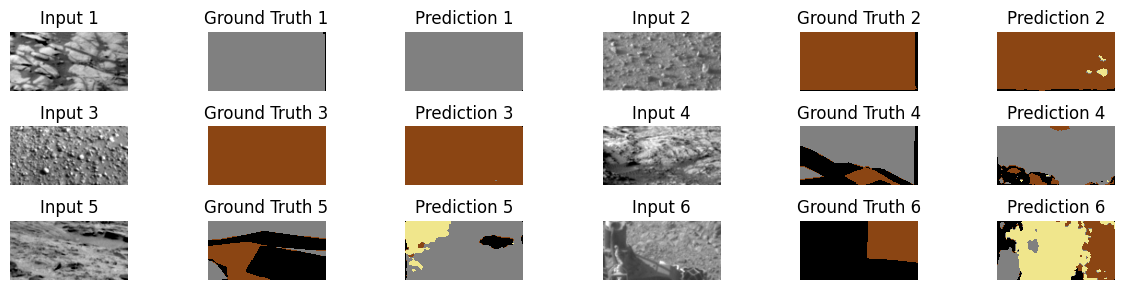

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.8023 - loss: 0.4183 - mean_iou: 0.6300 - val_accuracy: 0.5702 - val_loss: 1.3058 - val_mean_iou: 0.3268 - learning_rate: 2.5000e-04
Epoch 52/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7993 - loss: 0.4269 - mean_iou: 0.6283
Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.7993 - loss: 0.4269 - mean_iou: 0.6281 - val_accuracy: 0.6069 - val_loss: 1.1703 - val_mean_iou: 0.3382 - learning_rate: 2.5000e-04
Final validation Mean Intersection Over Union: 40.81%


In [16]:
mean_iou = tfk.metrics.MeanIoU(num_classes=5, ignore_class=0, sparse_y_pred=False, name='mean_iou')

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(LEARNING_RATE),
    metrics=["accuracy", mean_iou]
)
print("Model compiled!")

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1
)

n = 6
viz_callback = VizCallback(val_dataset, frequency=10, n=n)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping, viz_callback],
    verbose=1,
    class_weight=class_weights_dict
).history

final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

In [17]:
model_filename = f'Simple_Double_UNet_{str(final_val_meanIoU)}_aug4.keras'

if (on_kaggle):
    model_filename = f"/kaggle/working/{model_filename}"

model.save(model_filename)
print(f"Model saved to {model_filename}")

Model saved to /kaggle/working/Simple_Double_UNet_40.81_aug4.keras


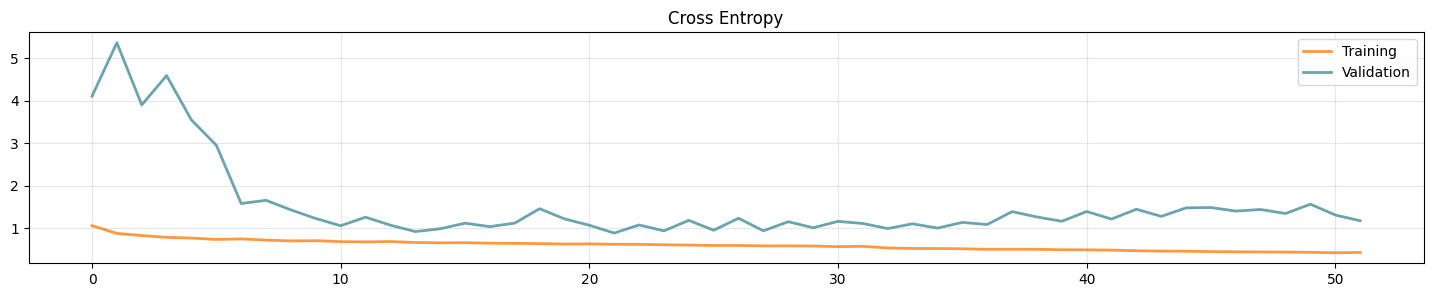

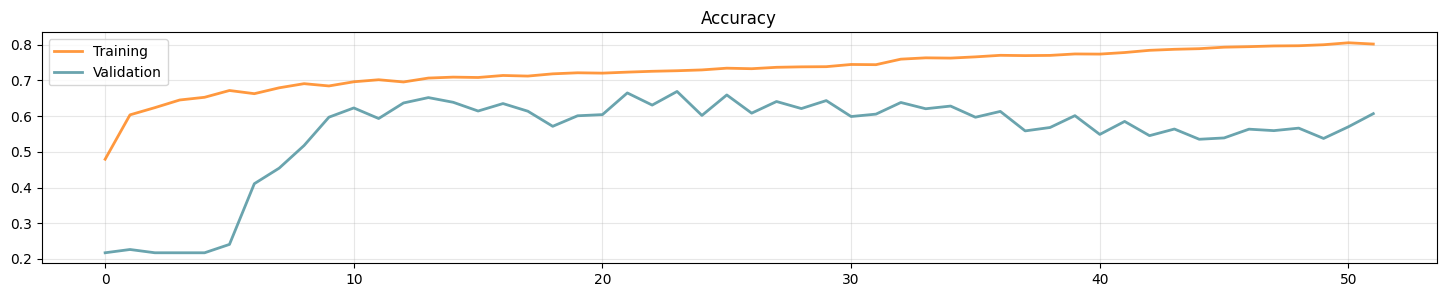

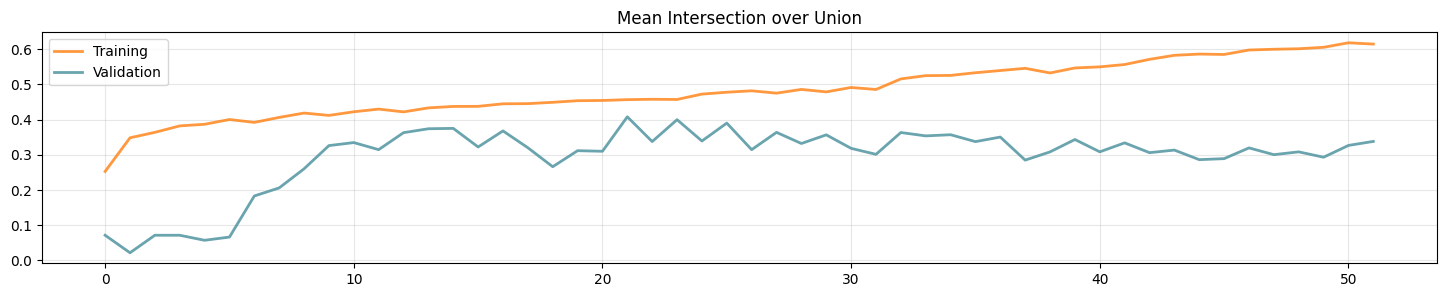

In [18]:
plt.figure(figsize=(18, 3))
plt.plot(history['loss'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_loss'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Cross Entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['accuracy'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_accuracy'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(18, 3))
plt.plot(history['mean_iou'], label='Training', alpha=0.8, color='#ff7f0e', linewidth=2)
plt.plot(history['val_mean_iou'], label='Validation', alpha=0.9, color='#5a9aa5', linewidth=2)
plt.title('Mean Intersection over Union')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.



Model loaded from /kaggle/working/Simple_Double_UNet_40.81_aug4.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step
Predictions shape: (10022, 64, 128)
Class counts: [ 8316030 24380102 28739580 20567794    96718]


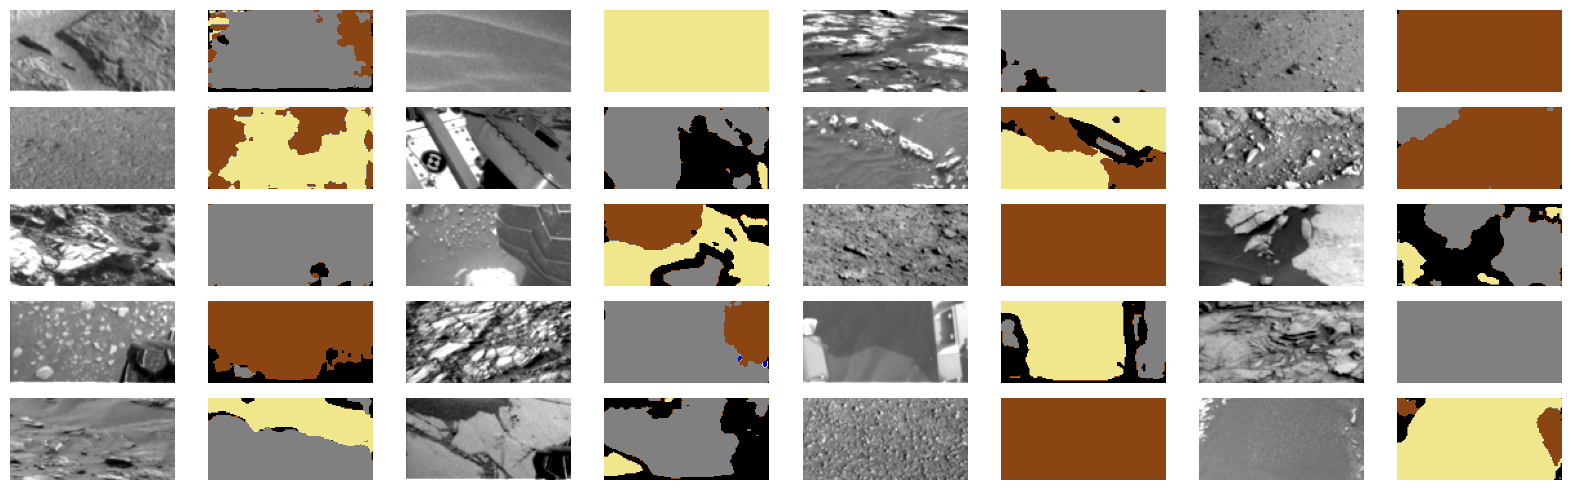

In [19]:
model_pred = tfk.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

X_test = apply_preprocessing(X_test_original) 
X_test = tf.cast(X_test, tf.float32)

preds = model_pred.predict(X_test)
preds = np.argmax(preds, axis=-1)
class_counts = np.bincount(preds.flatten(), minlength=5)

print(f"Predictions shape: {preds.shape}")
print(f"Class counts: {class_counts}")
plot_image_label(X_test, preds, 5, 4, 1)

In [20]:
import zipfile
import pandas as pd
import numpy as np

def y_to_df(y) -> pd.DataFrame:
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

submission_df = y_to_df(preds)
submission_filename = model_filename.replace(".keras", ".csv")
zip_filename = model_filename.replace(".keras", ".zip")
submission_df.to_csv(submission_filename, index=False)

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    filename = submission_filename.replace("/kaggle/working/", "")
    zipf.write(submission_filename, arcname=filename)

os.remove(submission_filename)
print("Zip file with CSV created successfully!")

Zip file with CSV created successfully!
